In [32]:
import tensorflow as tf
import matplotlib.pyplot as plt
from typing import Tuple, Optional
import numpy as np

class LidDrivenCavityPINN:
    def __init__(self, config: Optional[dict] = None):
        """
        Initialize the lid-driven cavity PINN solver with configuration.
        
        Args:
            config: Dictionary containing configuration parameters. If None, defaults will be used.
        """
        # Set default configuration
        self.default_config = {
            'domain': {
                'x_min': 0.0,
                'x_max': 1.0,
                'y_min': 0.0,
                'y_max': 1.0
            },
            'physics': {
                'U_lid': 1.0,
                'nu': 0.025  # kinematic viscosity
            },
            'training': {
                'N_f': 5000,  # Number of collocation points
                'N_b': 500,   # Number of boundary points
                'target_loss': 0.003,
                'max_epochs': 50000,
                'learning_rate': 1e-3
            },
            'model': {
                'num_shared_layers': 5,
                'num_head_layers': 2,
                'num_neurons': 40,
                'activation': 'tanh'
            }
        }
        
        # Update with user-provided config
        self.config = {**self.default_config, **(config or {})}
        
        # Initialize model and data
        self.model = self._build_model()
        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=self.config['training']['learning_rate']
        )
        self._generate_data()

        # Initialize loss tracking
        self.loss_history = {
                'total_loss': [],
                'pde_loss': [],
                'bc_loss': [],
                'epoch_times': []
            }
        self.start_time = None
        
    def _build_model(self) -> tf.keras.Model:
        """Build the enhanced PINN model architecture."""
        num_shared = self.config['model']['num_shared_layers']
        num_head = self.config['model']['num_head_layers']
        num_neurons = self.config['model']['num_neurons']
        activation = self.config['model']['activation']
        
        inputs = tf.keras.Input(shape=(2,))
        x, y = inputs[:, 0:1], inputs[:, 1:2]
        
        # Feature expansion
        X = tf.concat([inputs, tf.sin(inputs), tf.cos(inputs)], axis=1)
        
        # Shared layers
        for _ in range(num_shared):
            X = tf.keras.layers.Dense(
                num_neurons, 
                activation=activation, 
                kernel_initializer='glorot_normal'
            )(X)
        
        # Separate heads
        def build_head(X):
            for _ in range(num_head):
                X = tf.keras.layers.Dense(
                    num_neurons, 
                    activation=activation, 
                    kernel_initializer='glorot_normal'
                )(X)
            return X
        
        # u head
        uX = build_head(X)
        u = tf.keras.layers.Dense(1, activation=None)(uX)
        
        # v head
        vX = build_head(X)
        v = tf.keras.layers.Dense(1, activation=None)(vX)
        
        # p head
        pX = build_head(X)
        p = tf.keras.layers.Dense(1, activation=None)(pX)
        
        return tf.keras.Model(inputs=inputs, outputs=[u, v, p])
    
    def _generate_data(self) -> None:
        """Generate collocation and boundary points."""
        cfg = self.config
        N_f = cfg['training']['N_f']
        N_b = cfg['training']['N_b']
        
        # Collocation points
        x_f = tf.random.uniform((N_f, 1), cfg['domain']['x_min'], cfg['domain']['x_max'], dtype=tf.float32)
        y_f = tf.random.uniform((N_f, 1), cfg['domain']['y_min'], cfg['domain']['y_max'], dtype=tf.float32)
        self.X_f = tf.concat([x_f, y_f], axis=1)
        
        # Boundary points (split equally among 4 boundaries)
        N_b_per_edge = N_b // 4
        
        # Left boundary
        x_left = cfg['domain']['x_min'] * tf.ones((N_b_per_edge, 1), dtype=tf.float32)
        y_left = tf.random.uniform((N_b_per_edge, 1), cfg['domain']['y_min'], cfg['domain']['y_max'], dtype=tf.float32)
        
        # Right boundary
        x_right = cfg['domain']['x_max'] * tf.ones((N_b_per_edge, 1), dtype=tf.float32)
        y_right = tf.random.uniform((N_b_per_edge, 1), cfg['domain']['y_min'], cfg['domain']['y_max'], dtype=tf.float32)
        
        # Bottom boundary
        x_bottom = tf.random.uniform((N_b_per_edge, 1), cfg['domain']['x_min'], cfg['domain']['x_max'], dtype=tf.float32)
        y_bottom = cfg['domain']['y_min'] * tf.ones((N_b_per_edge, 1), dtype=tf.float32)
        
        # Top boundary
        x_top = tf.random.uniform((N_b_per_edge, 1), cfg['domain']['x_min'], cfg['domain']['x_max'], dtype=tf.float32)
        y_top = cfg['domain']['y_max'] * tf.ones((N_b_per_edge, 1), dtype=tf.float32)
        
        self.X_b = tf.concat([
            tf.concat([x_left, y_left], axis=1),
            tf.concat([x_right, y_right], axis=1),
            tf.concat([x_bottom, y_bottom], axis=1),
            tf.concat([x_top, y_top], axis=1)
        ], axis=0)
        
        # Boundary conditions
        U_lid = cfg['physics']['U_lid']
        self.u_b = tf.concat([
            tf.zeros((3 * N_b_per_edge, 1), dtype=tf.float32),  # u=0 on side and bottom
            U_lid * tf.ones((N_b_per_edge, 1), dtype=tf.float32)  # u=U_lid on top
        ], axis=0)
        
        self.v_b = tf.zeros((N_b, 1), dtype=tf.float32)  # v=0 everywhere on boundary
    
    def _compute_losses(self, X_f: tf.Tensor, X_b: tf.Tensor, u_b: tf.Tensor, v_b: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """Compute PDE and boundary condition losses."""
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(X_f)
            u, v, p = self.model(X_f)
            u = tf.squeeze(u)
            v = tf.squeeze(v)
            p = tf.squeeze(p)

            # First derivatives
            u_x = tape.gradient(u, X_f)[:, 0]
            u_y = tape.gradient(u, X_f)[:, 1]
            v_x = tape.gradient(v, X_f)[:, 0]
            v_y = tape.gradient(v, X_f)[:, 1]

            continuity = u_x + v_y

            # Second derivatives
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch(X_f)
                u, v, p = self.model(X_f)
                u = tf.squeeze(u)
                v = tf.squeeze(v)
                p = tf.squeeze(p)

                u_x = tape.gradient(u, X_f)[:, 0]
                u_y = tape.gradient(u, X_f)[:, 1]
                v_x = tape.gradient(v, X_f)[:, 0]
                v_y = tape.gradient(v, X_f)[:, 1]

            u_xx = tape2.gradient(u_x, X_f)[:, 0]
            u_yy = tape2.gradient(u_y, X_f)[:, 1]
            v_xx = tape2.gradient(v_x, X_f)[:, 0]
            v_yy = tape2.gradient(v_y, X_f)[:, 1]

            # Pressure gradients
            p_x = tape.gradient(p, X_f)[:, 0]
            p_y = tape.gradient(p, X_f)[:, 1]

            # Momentum equations
            momentum_u = u * u_x + v * u_y + p_x - self.config['physics']['nu'] * (u_xx + u_yy)
            momentum_v = u * v_x + v * v_y + p_y - self.config['physics']['nu'] * (v_xx + v_yy)

            # PDE loss
            f_pde = tf.reduce_mean(tf.square(continuity)) + \
                    tf.reduce_mean(tf.square(momentum_u)) + \
                    tf.reduce_mean(tf.square(momentum_v))

        # Boundary condition loss
        u_pred_b, v_pred_b, _ = self.model(X_b)
        bc_loss = tf.reduce_mean(tf.square(u_pred_b - u_b)) + \
                  tf.reduce_mean(tf.square(v_pred_b - v_b))

        total_loss = f_pde + bc_loss
        # total_loss = f_pde + tf.maximum(2.4 * bc_loss, 0.008)
        return total_loss, f_pde, bc_loss
    
    @tf.function
    def _train_step(self) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """Single training step."""
        with tf.GradientTape() as tape:
            total_loss, pde_loss, bc_loss = self._compute_losses(
                self.X_f, self.X_b, self.u_b, self.v_b
            )
        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        return total_loss, pde_loss, bc_loss
    
    def train(self) -> None:
        """Train the model until target loss or max epochs is reached."""
        target_loss = self.config['training']['target_loss']
        max_epochs = self.config['training']['max_epochs']
        
        self.start_time = tf.timestamp()
        
        for epoch in range(max_epochs):
            total_loss, pde_loss, bc_loss = self._train_step()
            
            # Store losses
            self.loss_history['total_loss'].append(total_loss.numpy())
            self.loss_history['pde_loss'].append(pde_loss.numpy())
            self.loss_history['bc_loss'].append(bc_loss.numpy())
            self.loss_history['epoch_times'].append(tf.timestamp().numpy() - self.start_time.numpy())
            
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Total Loss = {total_loss.numpy():.4e}, "
                      f"PDE Loss = {pde_loss.numpy():.4e}, BC Loss = {bc_loss.numpy():.4e}")
            
            if total_loss <= target_loss:
                print(f"Training converged at epoch {epoch} with loss {total_loss.numpy():.4e}")
                break
        
        if epoch == max_epochs - 1:
            print(f"Reached maximum epochs ({max_epochs}) with final loss {total_loss.numpy():.4e}")

    
    def plot_training_points(self) -> None:
        """Visualize the collocation and boundary points."""
        X_f_np = self.X_f.numpy()
        X_b_np = self.X_b.numpy()
        
        plt.figure(figsize=(8, 8))
        plt.scatter(X_f_np[:, 0], X_f_np[:, 1], color='skyblue', s=1, 
                   label='Collocation Points', alpha=0.5)
        plt.scatter(X_b_np[:, 0], X_b_np[:, 1], color='crimson', s=10, 
                   label='Boundary Points', alpha=0.8)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('PINN: Collocation vs Boundary Points')
        plt.legend()
        plt.grid(True)
        plt.axis('square')
        plt.show()

    

    def plot_velocity_contour(self, resolution: int = 100, dpi: int = 100) -> None:
        """
        Plot the velocity magnitude as filled contours.
        
        Args:
            resolution: Number of grid points in each direction
            dpi: Resolution of the output figure
        """
        x_plot = tf.linspace(self.config['domain']['x_min'], 
                            self.config['domain']['x_max'], 
                            resolution)
        y_plot = tf.linspace(self.config['domain']['y_min'], 
                            self.config['domain']['y_max'], 
                            resolution)
        X_grid, Y_grid = tf.meshgrid(x_plot, y_plot)
        XY = tf.stack([tf.reshape(X_grid, [-1]), tf.reshape(Y_grid, [-1])], axis=1)

        u_pred, v_pred, _ = self.model(XY)
        u_pred = tf.reshape(u_pred, (resolution, resolution)).numpy()
        v_pred = tf.reshape(v_pred, (resolution, resolution)).numpy()
        speed = np.sqrt(u_pred**2 + v_pred**2)

        fig, ax = plt.subplots(figsize=(5.5, 4), dpi=dpi)
        contour = ax.contourf(
            X_grid.numpy(), Y_grid.numpy(),
            speed,
            levels=100,
            cmap='coolwarm'
        )

        cbar = fig.colorbar(contour, ax=ax, pad=0.02)
        cbar.set_label('Velocity Magnitude', fontsize=10)

        ax.set_title('Velocity Magnitude Field', fontsize=11)
        ax.set_xlabel('x', fontsize=10)
        ax.set_ylabel('y', fontsize=10)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=8)
        plt.tight_layout()
        plt.show()

    def find_vortex_center(self, wall: str = 'left', margin: float = 0.2, grid_res: int = 200) -> np.ndarray:
        """
        Find the approximate center of secondary vortex near specified wall.
        
        Args:
            wall: 'left' or 'right' wall to search near
            margin: Fraction of domain to search from wall (0-1)
            grid_res: Resolution of the search grid
        Returns:
            vortex_center (x, y) coordinates
        """
        assert wall in ['left', 'right'], "wall must be 'left' or 'right'"
        
        domain = self.config['domain']
        if wall == 'left':
            x_start, x_end = domain['x_min'], domain['x_min'] + margin * (domain['x_max'] - domain['x_min'])
        else:
            x_start, x_end = domain['x_max'] - margin * (domain['x_max'] - domain['x_min']), domain['x_max']

        y_start, y_end = domain['y_min'], domain['y_min'] + margin * (domain['y_max'] - domain['y_min'])

        x = tf.linspace(x_start, x_end, grid_res)
        y = tf.linspace(y_start, y_end, grid_res)
        X, Y = tf.meshgrid(x, y)
        points = tf.stack([tf.reshape(X, [-1]), tf.reshape(Y, [-1])], axis=1)

        u_pred, v_pred, _ = self.model(points)
        u = tf.squeeze(u_pred).numpy()
        v = tf.squeeze(v_pred).numpy()

        vel_mag = np.sqrt(u**2 + v**2)
        min_idx = np.argmin(vel_mag)
        vortex_center = points[min_idx].numpy()

        print(f"{wall.capitalize()} wall vortex center approx at: x = {vortex_center[0]:.4f}, y = {vortex_center[1]:.4f}")
        return vortex_center

    def save_contour_plot(self, filename: str = 'velocity_contour.png', 
                         resolution: int = 1000, dpi: int = 300) -> None:
        """
        Save a high-quality contour plot of velocity magnitude.
        
        Args:
            filename: Output filename (can be .png or .pdf)
            resolution: Grid resolution
            dpi: Image resolution
        """
        x_plot = tf.linspace(self.config['domain']['x_min'], 
                            self.config['domain']['x_max'], 
                            resolution)
        y_plot = tf.linspace(self.config['domain']['y_min'], 
                            self.config['domain']['y_max'], 
                            resolution)
        X_grid, Y_grid = tf.meshgrid(x_plot, y_plot)
        XY = tf.stack([tf.reshape(X_grid, [-1]), tf.reshape(Y_grid, [-1])], axis=1)

        u_pred, v_pred, _ = self.model(XY)
        u_pred = tf.reshape(u_pred, (resolution, resolution)).numpy()
        v_pred = tf.reshape(v_pred, (resolution, resolution)).numpy()
        speed = np.sqrt(u_pred**2 + v_pred**2)

        fig, ax = plt.subplots(figsize=(5.5, 4), dpi=dpi)
        contour = ax.contourf(
            X_grid.numpy(), Y_grid.numpy(),
            speed,
            levels=100,
            cmap='coolwarm'
        )

        cbar = fig.colorbar(contour, ax=ax, pad=0.02)
        cbar.set_label('Velocity Magnitude', fontsize=10)

        ax.set_title('Velocity Magnitude Field', fontsize=11)
        ax.set_xlabel('x', fontsize=10)
        ax.set_ylabel('y', fontsize=10)
        ax.set_aspect('equal')
        ax.tick_params(labelsize=8)
        plt.tight_layout()
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')
        plt.close()


    def plot_comparison_figure(self, ghia_data: dict, resolution: int = 50, dpi: int = 100, save_path: str = None) -> None:
        """
        Generate complete comparison figure with streamlines and validation plots.
    
        Args:
            ghia_data: Dictionary containing Ghia's benchmark data
            resolution: Resolution for streamline plot
            dpi: Figure resolution
            save_path: If provided, saves the figure to this path
        """
        fig = plt.figure(figsize=(15, 5), dpi=dpi)
        gs = fig.add_gridspec(1, 3)
        
        # Subplot a: Streamlines
        ax1 = fig.add_subplot(gs[0, 0])
        self._plot_streamlines(ax1, resolution)
        ax1.set_title('a) Predicted Streamlines (Re={})'.format(int(1/self.config['physics']['nu'])))
        
        # Subplot b: Vertical centerline
        ax2 = fig.add_subplot(gs[0, 1])
        self._plot_vertical_centerline(ax2, ghia_data)
        ax2.set_title('b) Vertical Centerline Velocity')
        
        # Subplot c: Horizontal centerline
        ax3 = fig.add_subplot(gs[0, 2])
        self._plot_horizontal_centerline(ax3, ghia_data)
        ax3.set_title('c) Horizontal Centerline Velocity')
        
        plt.tight_layout()
        
        if save_path is not None:
            plt.savefig(save_path, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        else:
            plt.show()
    


    def _plot_streamlines(self, ax, resolution: int) -> None:
        """Helper method to plot streamlines on given axis."""
        x_plot = tf.linspace(self.config['domain']['x_min'], 
                            self.config['domain']['x_max'], 
                            resolution)
        y_plot = tf.linspace(self.config['domain']['y_min'], 
                            self.config['domain']['y_max'], 
                            resolution)
        X_grid, Y_grid = tf.meshgrid(x_plot, y_plot)
        XY = tf.stack([tf.reshape(X_grid, [-1]), tf.reshape(Y_grid, [-1])], axis=1)

        u_pred, v_pred, _ = self.model(XY)
        u_pred = tf.reshape(u_pred, (resolution, resolution)).numpy()
        v_pred = tf.reshape(v_pred, (resolution, resolution)).numpy()

        ax.streamplot(
            X_grid.numpy(), Y_grid.numpy(),
            u_pred, v_pred, 
            density=2, 
            linewidth=1, 
            arrowsize=1,
            color=np.sqrt(u_pred**2 + v_pred**2),
            cmap='coolwarm'
        )
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_xlim(self.config['domain']['x_min'], self.config['domain']['x_max'])
        ax.set_ylim(self.config['domain']['y_min'], self.config['domain']['y_max'])
        ax.set_aspect('equal')

    def _plot_vertical_centerline(self, ax, ghia_data: dict, resolution: int = 100) -> None:
        """Helper method to plot vertical centerline comparison."""
        y_vertical = tf.linspace(self.config['domain']['y_min'], 
                               self.config['domain']['y_max'], 
                               resolution)
        x_vertical = 0.5 * (self.config['domain']['x_min'] + self.config['domain']['x_max']) * tf.ones_like(y_vertical)
        xy_vertical = tf.stack([x_vertical, y_vertical], axis=1)
        u_pred, _, _ = self.model(xy_vertical)
        
        ax.plot(u_pred.numpy().flatten(), y_vertical.numpy(), 'r-', label='PINN Prediction')
        ax.plot(ghia_data['u_vertical'][1], ghia_data['u_vertical'][0], 'ko', label='Ghia et al.')
        ax.set_xlabel('Horizontal Velocity (u)')
        ax.set_ylabel('y-coordinate')
        ax.legend()
        ax.grid(True)

    def _plot_horizontal_centerline(self, ax, ghia_data: dict, resolution: int = 100) -> None:
        """Helper method to plot horizontal centerline comparison."""
        x_horizontal = tf.linspace(self.config['domain']['x_min'], 
                                 self.config['domain']['x_max'], 
                                 resolution)
        y_horizontal = 0.5 * (self.config['domain']['y_min'] + self.config['domain']['y_max']) * tf.ones_like(x_horizontal)
        xy_horizontal = tf.stack([x_horizontal, y_horizontal], axis=1)
        _, v_pred, _ = self.model(xy_horizontal)
        
        ax.plot(x_horizontal.numpy(), v_pred.numpy().flatten(), 'b-', label='PINN Prediction')
        ax.plot(ghia_data['v_horizontal'][0], ghia_data['v_horizontal'][1], 'ko', label='Ghia et al.')
        ax.set_xlabel('x-coordinate')
        ax.set_ylabel('Vertical Velocity (v)')
        ax.legend()
        ax.grid(True)

    def plot_loss_history(self, log_scale: bool = True, figsize: Tuple[float, float] = (12, 6), save_path: str = None) -> None:
        """
        Plot the training loss history.
        
        Args:
            log_scale: Whether to use logarithmic scale for y-axis
            figsize: Figure size (width, height)
            save_path: If provided, saves the figure to this path
        """
        plt.figure(figsize=figsize)
        
        epochs = range(len(self.loss_history['total_loss']))
        
        if log_scale:
            plt.semilogy(epochs, self.loss_history['total_loss'], label='Total Loss')
            plt.semilogy(epochs, self.loss_history['pde_loss'], label='PDE Loss')
            plt.semilogy(epochs, self.loss_history['bc_loss'], label='BC Loss')
        else:
            plt.plot(epochs, self.loss_history['total_loss'], label='Total Loss')
            plt.plot(epochs, self.loss_history['pde_loss'], label='PDE Loss')
            plt.plot(epochs, self.loss_history['bc_loss'], label='BC Loss')
        
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss History')
        plt.legend()
        plt.grid(True, which="both", ls="-")
        plt.tight_layout()
        
        if save_path is not None:
            plt.savefig(save_path, bbox_inches='tight')
            print(f"Figure saved to {save_path}")
        else:
            plt.show()
     
    
    def get_loss_history(self) -> dict:
        """
        Return the complete loss history dictionary.
        
        Returns:
            Dictionary containing:
                'total_loss': List of total loss values
                'pde_loss': List of PDE loss values
                'bc_loss': List of boundary condition loss values
                'epoch_times': List of cumulative time per epoch
        """
        return self.loss_history
    
        
    
ghia_data_100 = {
    'u_vertical': (
        np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]),  # y positions
        np.array([0.00000, -0.03717, -0.04192, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090, 0.20581, -0.13641, 0.00332, 0.23151, 0.68717, 0.73722, 0.78871, 0.84123, 1.00000])  # u velocities
    ),
    'v_horizontal': (
        np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]),  # x positions
        np.array([0.00000, 0.09233, 0.10091, 0.10890, 0.12317, 0.16077, 0.17507, 0.17527, 0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000])  # v velocities
    )
}


ghia_data_400 = {
    'u_vertical': (
        np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]),  # y positions
        np.array([0.00000, -0.08186, -0.09266, -0.10338, -0.14612, -0.24299, -0.32726, -0.17119, -0.11477, 0.02135, 0.16256, 0.29093, 0.55892, 0.61756, 0.68439, 0.75837, 1.00000])  # u velocities
    ),
    'v_horizontal': (
        np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]),  # x positions
        np.array([0.00000, 0.18360, 0.19713, 0.20920, 0.22965, 0.28124, 0.30203, 0.30174, 0.05186, -0.38598, -0.44993, -0.23827, -0.22847, -0.19254, -0.15663, -0.12146, 0.00000])  # v velocities
    )
}


In [33]:
# Example usage
config = {
            'domain': {
                'x_min': 0.0,
                'x_max': 1.0,
                'y_min': 0.0,
                'y_max': 1.0
            },
            'physics': {
                'U_lid': 1.0,
                'nu': 0.0025  # kinematic viscosity( re number 100)
            },
            'training': {
                'N_f': 10000,  # Number of collocation points
                'N_b': 500,   # Number of boundary points
                'target_loss': 0.005,
                'max_epochs': 50000,
                'learning_rate': 8e-4
            },
            'model': {
                'num_shared_layers': 12,
                'num_head_layers': 5,
                'num_neurons': 40,
                'activation': 'tanh'
            }
        }


In [34]:
# Create and train PINN
pinn = LidDrivenCavityPINN(config)  # Re=400
pinn.train()

Epoch 0: Total Loss = 6.0778e-01, PDE Loss = 1.5355e-01, BC Loss = 4.5423e-01
Epoch 100: Total Loss = 2.4207e-02, PDE Loss = 2.0735e-03, BC Loss = 2.2134e-02
Epoch 200: Total Loss = 1.4442e-02, PDE Loss = 1.6452e-03, BC Loss = 1.2797e-02
Epoch 300: Total Loss = 1.1890e-02, PDE Loss = 8.4078e-04, BC Loss = 1.1049e-02
Epoch 400: Total Loss = 1.1154e-02, PDE Loss = 1.0867e-03, BC Loss = 1.0067e-02
Epoch 500: Total Loss = 1.7558e-02, PDE Loss = 2.8925e-03, BC Loss = 1.4666e-02
Epoch 600: Total Loss = 9.6695e-03, PDE Loss = 5.9266e-04, BC Loss = 9.0769e-03
Epoch 700: Total Loss = 9.1628e-03, PDE Loss = 8.3488e-04, BC Loss = 8.3279e-03
Epoch 800: Total Loss = 8.3766e-03, PDE Loss = 5.7807e-04, BC Loss = 7.7985e-03
Epoch 900: Total Loss = 8.8313e-03, PDE Loss = 8.6821e-04, BC Loss = 7.9631e-03
Epoch 1000: Total Loss = 8.0615e-03, PDE Loss = 6.2786e-04, BC Loss = 7.4337e-03
Epoch 1100: Total Loss = 2.3942e-02, PDE Loss = 4.0936e-03, BC Loss = 1.9848e-02
Epoch 1200: Total Loss = 7.8533e-03, PDE

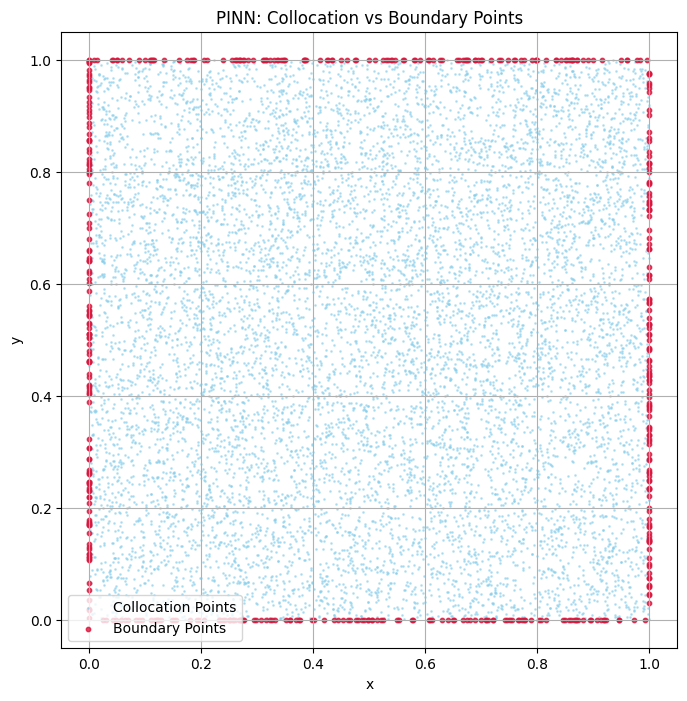

In [35]:
pinn.plot_training_points()

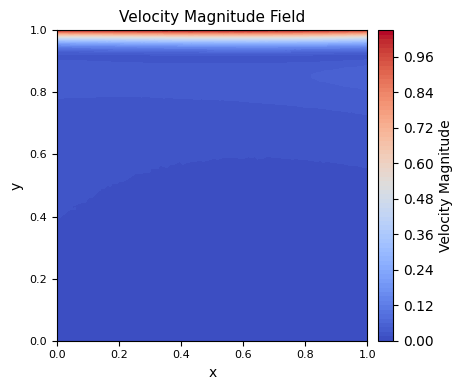

In [28]:
pinn.save_contour_plot('velocity_contour_400.png', 1000,  300) 
pinn.plot_velocity_contour()

In [29]:
pinn.find_vortex_center('left', 0.2,  200)


Left wall vortex center approx at: x = 0.1879, y = 0.0000


array([0.1879397, 0.       ], dtype=float32)

In [36]:
pinn.find_vortex_center('right', 0.2,  200)

Right wall vortex center approx at: x = 1.0000, y = 0.0201


array([1.       , 0.0201005], dtype=float32)

Figure saved to camp_400.png


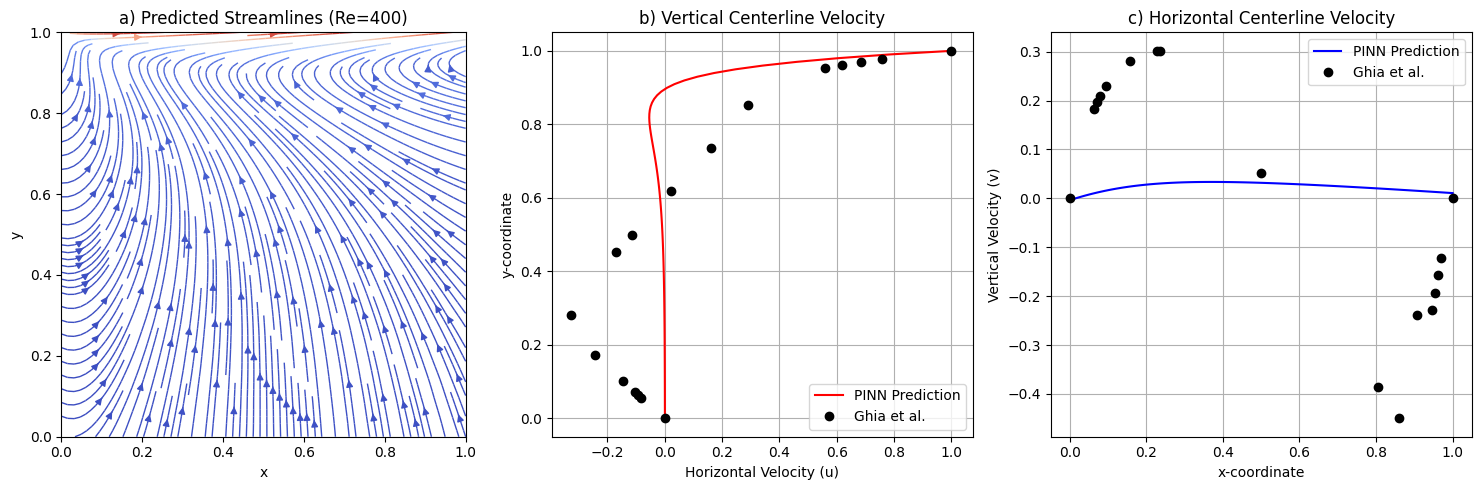

In [37]:
pinn.plot_comparison_figure( ghia_data_400,50,  100,"camp_400.png")

Figure saved to loss_400.png


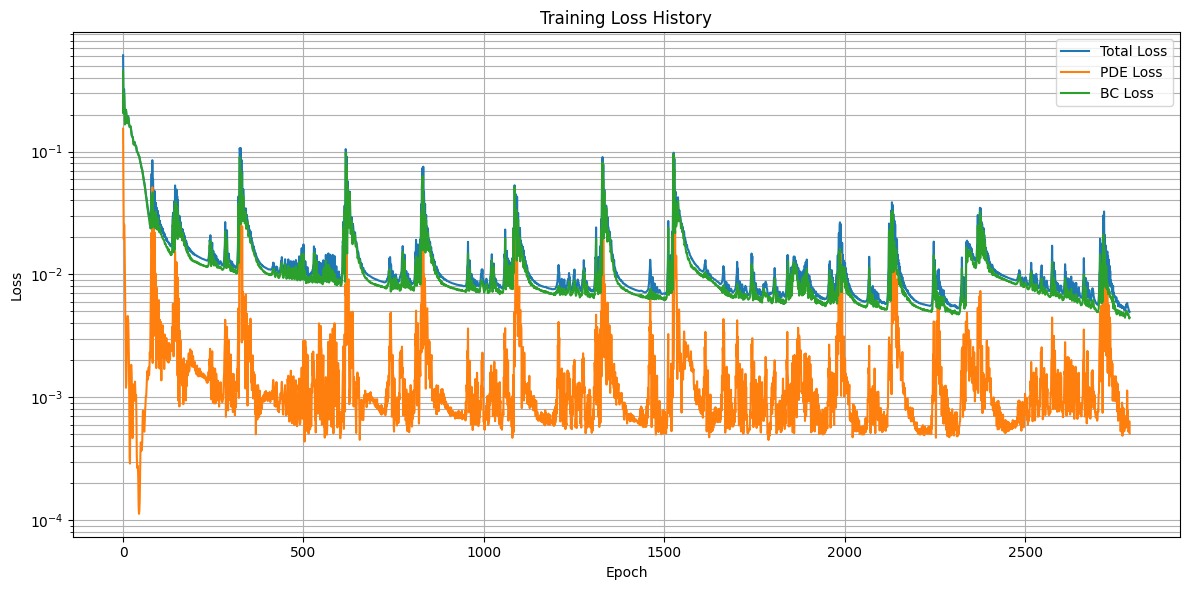

In [38]:
# After training
pinn.plot_loss_history(True, (12, 6),"loss_400.png")# Shows loss vs epochs on log scale


# To get the raw data
loss_data = pinn.get_loss_history()

In [39]:
pinn.save_contour_plot('velocity_contour_400.png', 1000,  300) 

In [11]:
ghia_data_100 = {
    'u_vertical': (
        np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]),  # y positions
        np.array([0.00000, -0.03717, -0.04192, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090, 0.20581, -0.13641, 0.00332, 0.23151, 0.68717, 0.73722, 0.78871, 0.84123, 1.00000])  # u velocities
    ),
    'v_horizontal': (
        np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]),  # x positions
        np.array([0.00000, 0.09233, 0.10091, 0.10890, 0.12317, 0.16077, 0.17507, 0.17527, 0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000])  # v velocities
    )
}

ghia_data_400 = {
    'u_vertical': (
        np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]),  # y positions
        np.array([0.00000, -0.08186, -0.09266, -0.10338, -0.14612, -0.24299, -0.32726, -0.17119, -0.11477, 0.02135, 0.16256, 0.29093, 0.55892, 0.61756, 0.68439, 0.75837, 1.00000])  # u velocities
    ),
    'v_horizontal': (
        np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]),  # x positions
        np.array([0.00000, 0.18360, 0.19713, 0.20920, 0.22965, 0.28124, 0.30203, 0.30174, 0.05186, -0.38598, -0.44993, -0.23827, -0.22847, -0.19254, -0.15663, -0.12146, 0.00000])  # v velocities
    )
}

ghia_data_1000 = {
    'u_vertical': (
        np.array([0.0000, 0.0547, 0.0625, 0.0703, 0.1016, 0.1719, 0.2813, 0.4531, 0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]),  # y positions
        np.array([0.00000, -0.18109, -0.20196, -0.22220, -0.29730, -0.38289, -0.27805, 0.10648, 0.31683, 0.38857, 0.30070, 0.10890, -0.05702, -0.07404, -0.08823, -0.09947, 0.00000])  # u velocities
    ),
    'v_horizontal': (
        np.array([0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344, 0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]),  # x positions
        np.array([0.00000, 0.27485, 0.29012, 0.30353, 0.32627, 0.37095, 0.33075, 0.32235, 0.02526, -0.31966, -0.42665, -0.51550, -0.39188, -0.33714, -0.27669, -0.21388, 0.00000])  # v velocities
    )
}

